<a href="https://colab.research.google.com/github/deniwidi/data-science-2026/blob/main/Pertemuan6_Deni_Widi_Alfian_240401010340.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pertemuan ke-5

- Nama    : Deni Widi Alfian
- NIM     : 240401010340
- Kelas   : IF405

## Langkah 1 — Load & EDA Singkat
Muat dataset, periksa missing values, tipe data, dan distribusi target.

In [18]:
import pandas as pd, seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')

# Pilih kolom yang akan digunakan
cols = ['pclass','sex','age','sibsp','parch','fare','embarked','survived']
df = df[cols].copy()

print('Shape dataset:', df.shape)

print('\nTipe data tiap kolom:')
print(df.dtypes)

print('\nMissing values per kolom:')
print(df.isnull().sum())

print('\nDistribusi target (survived):')
print(df['survived'].value_counts(normalize=True).round(3))
print('→ survived=0 (~61.6%) dan survived=1 (~38.4%) — kelas tidak seimbang!')

print('\nPreview 5 baris pertama:')
df.head()


Shape dataset: (891, 8)

Tipe data tiap kolom:
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
survived      int64
dtype: object

Missing values per kolom:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

Distribusi target (survived):
survived
0    0.616
1    0.384
Name: proportion, dtype: float64
→ survived=0 (~61.6%) dan survived=1 (~38.4%) — kelas tidak seimbang!

Preview 5 baris pertama:


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


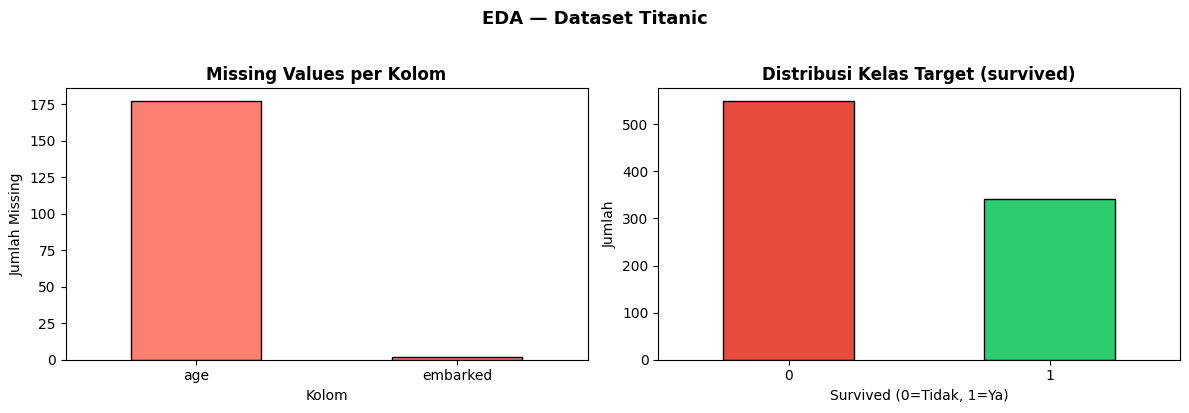

In [19]:
# Visualisasi distribusi missing values dan target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Missing values
missing = df.isnull().sum()
missing[missing > 0].plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Missing Values per Kolom', fontweight='bold')
axes[0].set_ylabel('Jumlah Missing')
axes[0].set_xlabel('Kolom')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: Distribusi target
df['survived'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#E74C3C', '#2ECC71'], edgecolor='black'
)
axes[1].set_title('Distribusi Kelas Target (survived)', fontweight='bold')
axes[1].set_ylabel('Jumlah')
axes[1].set_xlabel('Survived (0=Tidak, 1=Ya)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('EDA — Dataset Titanic', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Langkah 2 — Handling Missing Values
Isi nilai yang hilang sebelum encoding. Gunakan median untuk kolom numerik (robust
terhadap outlier) dan modus untuk kolom kategorikal.


In [20]:
# Age: isi dengan median (robust terhadap outlier)
df['age'] = df['age'].fillna(df['age'].median())

# Embarked: isi dengan modus (nilai paling sering)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print('Missing setelah handling:')
print(df.isnull().sum()) # Semua harus 0



Missing setelah handling:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


## Langkah 3 — Encoding Kategorikal
Terapkan One-Hot Encoding pada kolom 'sex' dan 'embarked'. Gunakan drop_first=True
untuk menghindari dummy variable trap.


In [21]:
# One-Hot Encoding untuk 'sex' dan 'embarked'
df = pd.get_dummies(df,
    columns=['sex', 'embarked'],
    drop_first=True, # hindari dummy variable trap
    dtype=int)

print('Kolom setelah encoding:')
print(df.columns.tolist())
# ['pclass','age','sibsp','parch','fare','survived',
# 'sex_male','embarked_Q','embarked_S']



Kolom setelah encoding:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']


## Langkah 4 — Train-Test Split (Stratified)
Bagi data dengan stratifikasi untuk menjaga proporsi kelas 'survived' di train dan test set.

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
      X, y,
      test_size=0.2,
      random_state=42,
      stratify=y # proporsi kelas terjaga
)

print(f'Train: {X_train.shape[0]} baris')
print(f'Test : {X_test.shape[0]} baris')
print('\nProporsi survived di Train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nProporsi survived di Test:')
print(y_test.value_counts(normalize=True).round(3))


Train: 712 baris
Test : 179 baris

Proporsi survived di Train:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Proporsi survived di Test:
survived
0    0.615
1    0.385
Name: proportion, dtype: float64


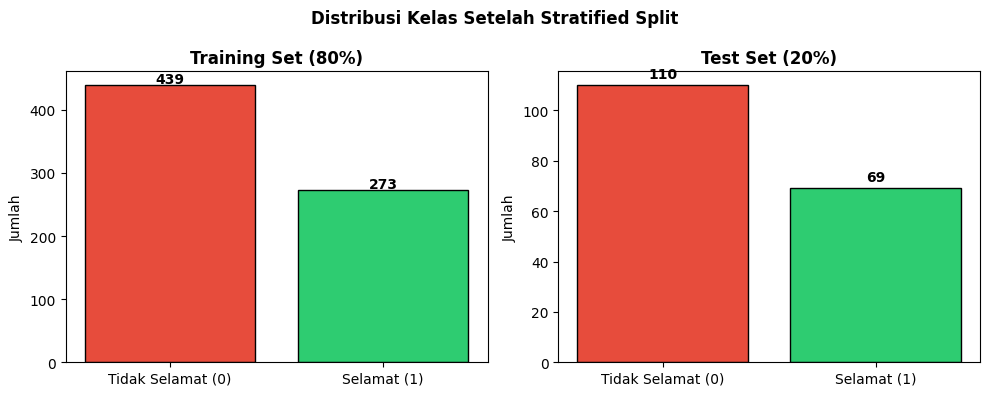

In [23]:
# Visualisasi proporsi kelas setelah split
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, data, label in zip(axes, [y_train, y_test], ['Training Set (80%)', 'Test Set (20%)']):
    counts = data.value_counts()
    bars = ax.bar(['Tidak Selamat (0)', 'Selamat (1)'],
                  [counts.get(0,0), counts.get(1,0)],
                  color=['#E74C3C', '#2ECC71'], edgecolor='black')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Jumlah')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 3,
                f'{bar.get_height()}', ha='center', fontweight='bold')

plt.suptitle('Distribusi Kelas Setelah Stratified Split', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Langkah 5 — Feature Scaling (StandardScaler)
Terapkan StandardScaler HANYA pada kolom numerik, fit pada training set, transform pada keduanya. Kolom biner hasil OHE tidak perlu di-scale.

In [24]:
from sklearn.preprocessing import StandardScaler

# Hanya kolom numerik yang perlu di-scale
# Kolom biner (sex_male, embarked_Q, embarked_S) TIDAK perlu
num_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']

scaler = StandardScaler()

# fit_transform pada training set (belajar μ dan σ dari sini)
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# transform saja pada test set (gunakan μ dan σ dari training!)
X_test[num_cols] = scaler.transform(X_test[num_cols])

print('Mean scaler (dari train):', scaler.mean_.round(2))
print('Std scaler (dari train):', scaler.scale_.round(2))
print()
print('Contoh X_train setelah scaling:')
print(X_train.head(3).round(3))

print('\nData siap dilatih model Machine Learning!')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}, y_test : {y_test.shape}')


Mean scaler (dari train): [ 2.31 29.46  0.49  0.39 31.82]
Std scaler (dari train): [ 0.83 13.03  1.06  0.84 48.03]

Contoh X_train setelah scaling:
     pclass    age  sibsp  parch   fare  sex_male  embarked_Q  embarked_S
692   0.830 -0.112 -0.465 -0.466  0.514         1           0           1
481  -0.371 -0.112 -0.465 -0.466 -0.663         1           0           1
527  -1.571 -0.112 -0.465 -0.466  3.955         1           0           1

Data siap dilatih model Machine Learning!
X_train: (712, 8), y_train: (712,)
X_test : (179, 8), y_test : (179,)


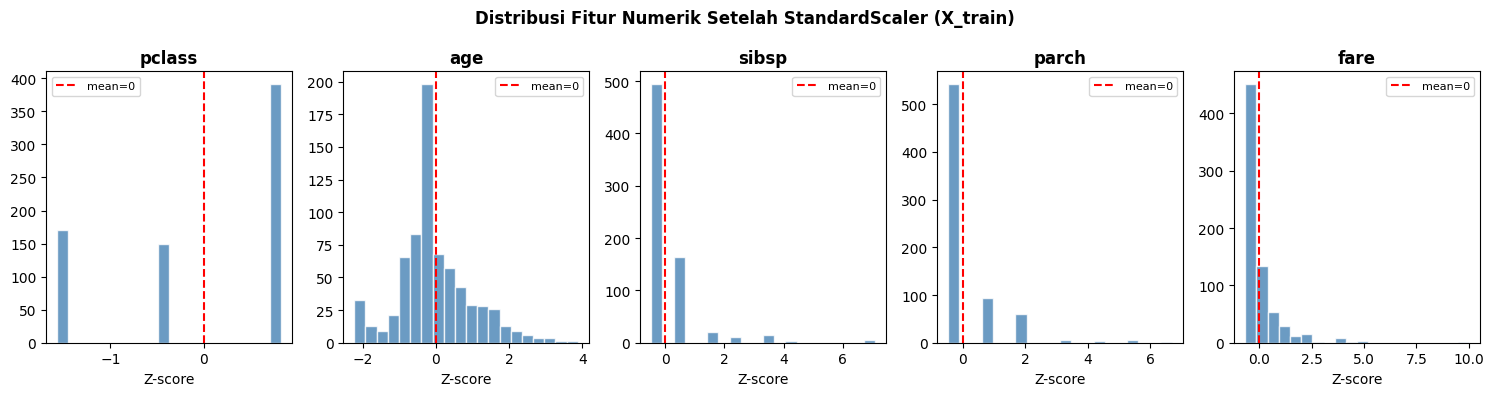

In [25]:
# Visualisasi distribusi fitur numerik setelah scaling (dari training set)
fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    ax.hist(X_train[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='mean=0')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('Z-score')
    ax.legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik Setelah StandardScaler (X_train)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
